# Homework 5: Midterm 1 practice exam

This practice exam has four sections *in the same order as the exam.*
Each section has short warm-ups followed by three questions about one code cell.
Predict each warm-up result before checking it in the [Homework 5 hints notebook](https://colab.research.google.com/github/wfreinhart/matse219/blob/main/notebooks/Homework05Hints.ipynb).
> Reading the cell's output isn't practice! You must predict it in advance.

Note that the exam itself won't include these "warm-up" sections.

This homework will be graded for completion:
a genuine attempt at every part earns credit even if the answer is wrong.

You may also run the cells at the bottom to check and revise your answers.

## Submission instructions

Upload the `ipynb` file to Canvas:
> File -> Download -> ipynb -> upload to Canvas (like any other file)

The `ipynb` file type is the only accepted format.
Save a copy before beginning.
Reloading or disconnecting can revert the notebook to the instructor copy.

# Problem 0 (-10 pts if blank): generative AI usage statement

As you work on this assignment, feel free to use generative AI tools to help you learn,
understand, and debug Python code. In particular, you could get hints or conceptual guidance in
the implementation you write yourself.

However, you must clearly disclose and cite all use of AI. You must include:
1. The name(s) of the AI tool(s) used.
2. The specific prompt(s) you used to generate the content.
3. A description of how you used the output and what edits or additions you made to integrate it
   into your own work.

You are fully responsible for the final submitted work. Critically evaluate, fact-check, and
verify all AI-generated content for validity. Failure to properly cite and disclose AI use
constitutes plagiarism under Penn State's Academic Integrity policy.

Write your disclosure (or "I did not use an AI tool for this assignment") in the cell below.

*your disclosure here*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. Python and NumPy (25 points)

A thermoelectric material turns a temperature difference into voltage.
Its figure of merit, zT, is dimensionless; higher values mean better performance.
The values below come from the tetrahedrite sample records used in class.

## Warm-up (8 points)

**1a (2 points).** What does this print?
```python
values = np.array([0.44, 0.45, 0.49, 0.64])
print(values[1:3])
```

*your answer here*

**1b (2 points).** What happens when this runs?
```python
sample = np.array(['Suekuni 2013', 0.50])
print(sample[1] - 0.10)
```

*your answer here*

**1c (2 points).** What does this print?
```python
pair = np.array([[0.44, 0.45], [0.50, 0.55]])
print(np.max(pair, axis=0))
```

*your answer here*

**1d (2 points).** Fill in the key that prints `0.5`.
```python
record = {'study': 'Suekuni 2013', 'best_zT': 0.50}
print(record[________])
```

*your answer here*

## Exam-style cell (17 points)

Read the code and its printed results before answering.

In [2]:
zt_350 = np.array([0.44, 0.45, 0.49, 0.64])    # zT of four samples measured at 350 °C
zt_best = np.array([0.50, 0.55, 0.56, 0.70])   # highest zT reported for the same four samples
zt_grid = np.array([zt_350, zt_best])
print(zt_grid.shape)                 # prints (2, 4)
print(zt_grid[:, 1])                 # prints [0.45 0.55]
print(np.max(zt_grid, axis=0))       # prints [0.5  0.55 0.56 0.7 ]

first_sample = {'study': 'Suekuni 2013',
                'zT_350C': 0.44, 'zT_max': 0.50}
print(first_sample['zT_max'])       # prints 0.5

(2, 4)
[0.45 0.55]
[0.5  0.55 0.56 0.7 ]
0.5


**1e (6 points).** What does one column of `zt_grid` describe?

*your answer here*

**1f (6 points).** What would `np.max(zt_grid, axis=1)` find instead of line 6?

*your answer here*

**1g (5 points).** Why does line 10 look up `'zT_max'` by name instead of by position?

*your answer here*

# 2. Descriptive statistics (25 points)

This section uses the yield strengths in a titanium alloy dataset, in MPa.
Yield strength is the stress at which an alloy begins to deform permanently.

In [3]:
#@title Load the Ti-alloy dataset (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd


def _find(name):
    return next(
        (p for p in (f'datasets/{name}', f'../datasets/{name}', f'../../datasets/{name}',
                     f'../../../datasets/{name}')
         if os.path.exists(p)),
        f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{name}',
    )


try:
    data = pd.read_csv(_find('biomaterials_ti_alloys.csv'))
except Exception as e:
    raise RuntimeError(
        "Could not load the Ti-alloy data. If you are in Colab, check your "
        "internet connection."
    ) from e

print(f'Loaded {len(data)} titanium alloys')
data[['eid', 'YS_MPa', 'UTS_MPa']].head()

Loaded 283 titanium alloys


,eid,YS_MPa,UTS_MPa
0,Ti-23Nb-10Zr-2.0Fe,782.0,NaN
1,Ti-27Nb-10Zr-1.5Fe,735.0,NaN
2,Ti-31Nb-10Zr-1.0Fe,672.0,NaN
3,Ti-11Nb-7Zr-3.5Fe,1011.0,NaN
4,Ti-19Nb-6Sn-2.5Fe,765.0,NaN


## Warm-up (8 points)

**2a (3 points).** What does this print?
```python
small = np.array([5.0, np.nan, 5.0])
print(np.mean(small))
print(np.nanmean(small))
```

*your answer here*

**2b (3 points).** What does this print?
```python
ordered = np.array([2.0, 3.0, 9.0])
print(np.median(ordered))
```

*your answer here*

**2c (2 points).** Fill in the NumPy function that prints `3.0`.
```python
print(np.________(ordered, 50))
```

*your answer here*

## Exam-style cell (17 points)

Read the code and its printed results before answering.

283 271
725.9 663.0
1143


Text(0, 0.5, 'number of alloys')

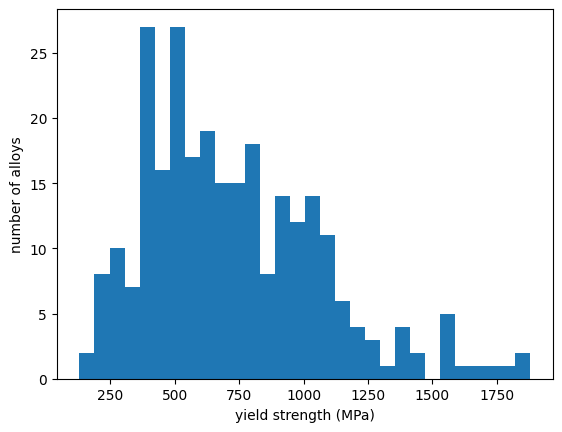

In [4]:
ys = data['YS_MPa'].dropna()
print(len(data), len(ys))                  # prints 283 271
print(f'{np.mean(ys):.1f} {np.median(ys):.1f}')
# prints 725.9 663.0
print(f'{np.percentile(ys, 90):.0f}')     # prints 1143

fig, ax = plt.subplots()
ax.hist(ys, bins=30)
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('number of alloys')

**2d (6 points).** Where do most of these alloys' yield strengths fall?

*your answer here*

**2e (6 points).** Why is the printed mean higher than the printed median?

*your answer here*

**2f (5 points).** What does the printed 1143 MPa tell you about these alloys?

*your answer here*

# 3. pandas, missing values, and filtering (25 points)

Each row of the corrosion table describes one test of a material in one specific chemical environment.
`rate_mm_yr_numeric` is the measured corrosion rate in millimeters per year.

In [5]:
#@title Load the NIST corrosion database (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd

_file = 'corrosion.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

print(f'Loaded {len(table)} corrosion tests from {_file}')
print(f'  {table["Environment"].nunique()} environments, {table["Material Family"].nunique()} material families')

Loaded 24721 corrosion tests from corrosion.csv
  288 environments, 90 material families


## Warm-up (8 points)

**3a (3 points).** What does this print?
```python
demo = pd.DataFrame({'row': [10, 20], 'rate': [0.1, 0.2]})
demo = demo.set_index('row')
print(demo.loc[10, 'rate'])
print(demo.iloc[1, 0])
```

*your answer here*

**3b (3 points).** What does this print?
```python
values = np.array([0.1, 0.2, 0.3])
keep = values > 0.1
print(np.sum(keep))
print(values[keep])
```

*your answer here*

**3c (2 points).** Fill in the method that marks rows with a recorded rate.
```python
has_rate = table['rate_mm_yr_numeric'].________()
```

*your answer here*

## Exam-style cell (17 points)

Read the code and its printed results before answering.

In [6]:
print(table[['Environment', 'rate_mm_yr_numeric']].dtypes)
# prints Environment             object
#        rate_mm_yr_numeric    float64

is_acid = table['Environment'] == 'Sulfuric Acid'
acid = table.loc[is_acid]
print(len(acid))                           # prints 2686

has_rate = acid['rate_mm_yr_numeric'].notna()
rated = acid.loc[has_rate]
print(len(rated))                          # prints 1154
print(np.median(rated['rate_mm_yr_numeric']))
# prints 0.5

Environment            object
rate_mm_yr_numeric    float64
dtype: object
2686
1154
0.5


**3d (7 points).** Why does the code print a length after each filter?

*your answer here*

**3e (5 points).** What does the drop from 2686 to 1154 tell you about rate reporting?

*your answer here*

**3f (5 points).** How would using `acid` change the result of the median calculation?

*your answer here*

# 4. Plotting, derived quantities, and correlation (25 points)

Each row of the superconductor table is one reported measurement.
`critical_temp` is the reported temperature in kelvin below which the material superconducts.

In [7]:
#@title Find the three-column superconductor table (click ▶ to run) { display-mode: "form" }
import os

_file = 'superconductors_l11.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (path for path in (
        f'datasets/{_file}',
        f'../datasets/{_file}',
        f'../../datasets/{_file}',
        f'../../../datasets/{_file}',
    ) if os.path.exists(path)),
    None,
)
source = _local if _local else _github

print(f'Ready to read {_file}')

Ready to read superconductors_l11.csv


## Warm-up (8 points)

**4a (3 points).** What does this print?
The expression is the reflected fraction of light computed from two optical constants, `n` and `k`.
```python
n = np.array([1.5, 2.0])
k = np.array([0.0, 0.0])
R = ((n - 1)**2 + k**2) / ((n + 1)**2 + k**2)
print(R.shape)
```

*your answer here*

**4b (3 points).** What does this print?
```python
x = np.array([1, 2, 3])
y = np.array([3, 2, 1])
r, p = stats.pearsonr(x, y)
print(f'{r:.0f}')
```

*your answer here*

**4c (2 points).** Fill in the plotting method that draws separate points.
```python
fig, ax = plt.subplots()
ax.________([1, 2, 3], [3, 2, 1])
```

*your answer here*

## Exam-style cell (17 points)

Read the code and its printed results before answering.

532
0.601


Text(0, 0.5, 'critical temperature (K)')

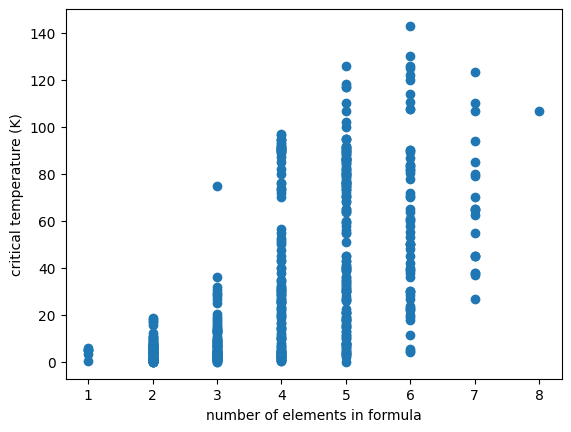

In [8]:
all_sc = pd.read_csv(source)
sc = all_sc.iloc[::40]                    # every 40th record
print(len(sc))                            # prints 532
x = sc['number_of_elements']
y = sc['critical_temp']
r, p = stats.pearsonr(x, y)
print(f'{r:.3f}')                         # prints 0.601

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_xlabel('number of elements in formula')
ax.set_ylabel('critical temperature (K)')

**4d (6 points).** What does the vertical spread at one element count show?

*your answer here*

**4e (6 points).** Why can the visible dots not be counted as individual records?

*your answer here*

**4f (5 points).** Why do the dots line up in vertical columns?

*your answer here*